========== 运行环境 ==========
使用设备: cuda
PyTorch版本: 2.8.0+cu128
NumPy版本: 1.23.4

========== 预训练Diffusion模型 ==========
Diffusion预训练Epoch 0 | Loss: 1.0227
Diffusion预训练Epoch 20 | Loss: 0.9862
Diffusion预训练Epoch 40 | Loss: 0.9913
Diffusion预训练Epoch 60 | Loss: 0.9766
Diffusion预训练Epoch 80 | Loss: 0.9700
Diffusion模型预训练完成！

========== 开始训练PPO模型 ==========
Epoch    0 | Avg Reward: -98.77 | Collision Rate: 0.97 | Explore Std: 0.100
Epoch   10 | Avg Reward: -101.72 | Collision Rate: 1.00 | Explore Std: 0.095
Epoch   20 | Avg Reward: -102.18 | Collision Rate: 1.00 | Explore Std: 0.090
Epoch   30 | Avg Reward: -99.73 | Collision Rate: 0.97 | Explore Std: 0.086
Epoch   40 | Avg Reward: -101.22 | Collision Rate: 0.98 | Explore Std: 0.081
Epoch   50 | Avg Reward: -99.72 | Collision Rate: 0.98 | Explore Std: 0.077
Epoch   60 | Avg Reward: -102.16 | Collision Rate: 1.00 | Explore Std: 0.074
Epoch   70 | Avg Reward: -100.21 | Collision Rate: 0.96 | Explore Std: 0.070
Epoch   80 | Avg Reward: -99.75 | Collisio

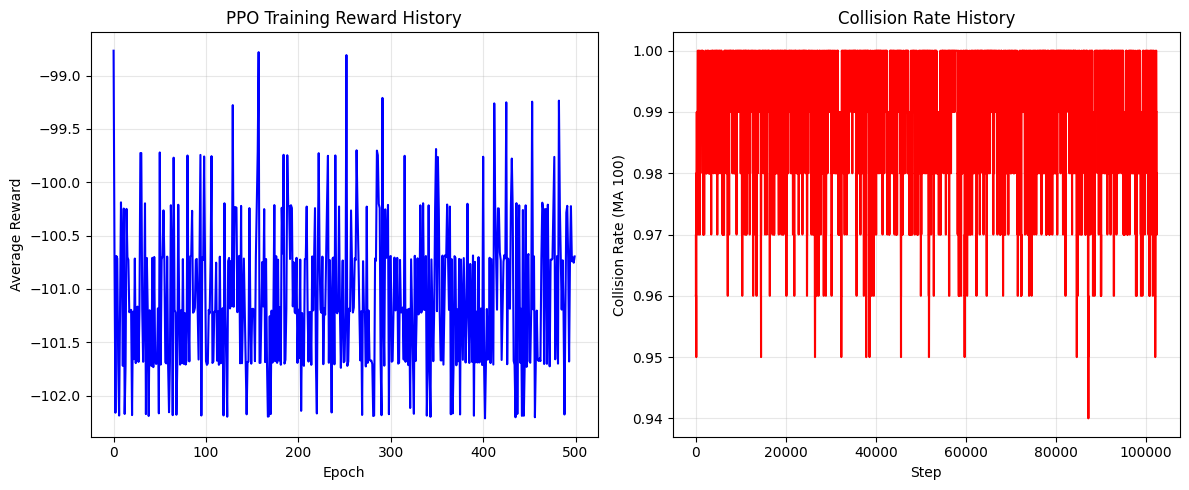


========== 测试生成轨迹 ==========
最终轨迹奖励：-102.08
是否碰撞障碍物：True
终点到目标距离：0.95
轨迹平滑度（速度方差）：0.81

========== 测试轨迹可视化 ==========


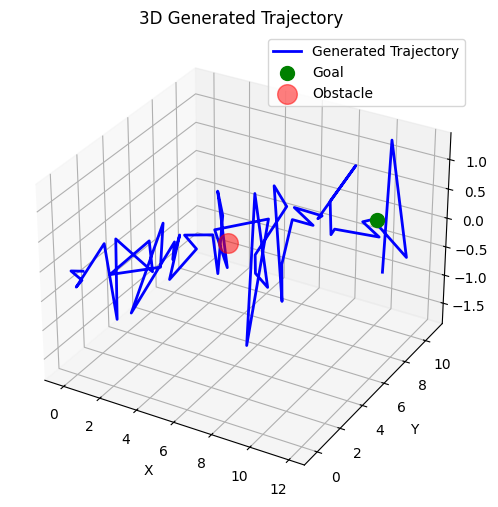

In [10]:
import torch
import torch.nn as nn
import numpy as np
from torch.optim import Adam
import random
from collections import deque
import matplotlib.pyplot as plt

# ====================== 1. 配置参数 ======================
class Config:
    # 轨迹参数
    traj_length = 50  # 轨迹点数量
    traj_dim = 3      # 3D轨迹（x,y,z）
    goal_pos = np.array([10.0, 10.0, 0.0])  # 目标位置
    obstacle_pos = np.array([5.0, 5.0, 0.0])  # 障碍物位置
    obstacle_radius = 1.0  # 障碍物半径

    # Diffusion 参数
    denoise_steps = 10  # 去噪步数（t从10→1，对应σ从大到小）
    guidance_scale = 1.0  # 引导尺度
    beta_start = 0.0001
    beta_end = 0.02
    betas = np.linspace(beta_start, beta_end, denoise_steps)
    alphas = 1.0 - betas
    alphas_cumprod = np.cumprod(alphas)
    alphas_cumprod_prev = np.concatenate([np.array([1.0]), alphas_cumprod[:-1]])

    # PPO 参数
    state_dim = 1 + 1 + traj_length*traj_dim + traj_length*traj_dim + traj_dim  # t + σ + x_t + noise_pred + goal
    action_dim = 6  # 简化动作维度（3维方向+3维权重）
    lr_actor = 3e-4
    lr_critic = 1e-3
    gamma = 0.99    # 折扣因子
    lam = 0.95      # GAE因子
    clip_epsilon = 0.2
    batch_size = 2048
    mini_batch_size = 64
    max_epochs = 500  # 减少训练轮数，加快收敛且避免内存溢出
    explore_std = 0.1  # 初始探索标准差
    std_decay = 0.995  # 探索标准差衰减率
    min_std = 0.01     # 最小探索标准差

# ====================== 2. Diffusion 基础模型 ======================
class DiffusionModel(nn.Module):
    """简单的扩散噪声预测模型（MLP）"""
    def __init__(self, traj_length=50, traj_dim=3, denoise_steps=10):
        super().__init__()
        self.traj_length = traj_length
        self.traj_dim = traj_dim
        self.denoise_steps = denoise_steps
        # 时间步嵌入
        self.time_emb = nn.Embedding(denoise_steps+1, 32)
        # 噪声预测网络
        self.mlp = nn.Sequential(
            nn.Linear(traj_length*traj_dim + 32, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, traj_length*traj_dim)
        )

    def forward(self, x_t, t):
        """
        x_t: 加噪轨迹 (batch, traj_length*traj_dim)
        t: 时间步 (batch,)
        """
        t_emb = self.time_emb(t)  # (batch, 32)
        x_input = torch.cat([x_t, t_emb], dim=1)  # (batch, traj_length*traj_dim + 32)
        noise_pred = self.mlp(x_input)  # (batch, traj_length*traj_dim)
        return noise_pred

    @torch.no_grad()  # 禁用梯度计算，避免计算图累积
    def predict_noise(self, x_t, step, device):
        """预测单条轨迹的噪声（新增device参数，同步设备）"""
        x_t_flat = torch.tensor(x_t.flatten(), dtype=torch.float32).unsqueeze(0).to(device)
        t = torch.tensor([step], dtype=torch.long).to(device)
        noise_pred = self.forward(x_t_flat, t)
        # 先转回CPU再转numpy（避免CUDA张量直接转numpy报错）
        return noise_pred.detach().cpu().numpy().reshape(self.traj_length, self.traj_dim)

    def denoise_step(self, x_t, noise_guided, step):
        """单步去噪（纯numpy运算，避免设备问题）"""
        t = step - 1  # 转换为0索引
        alpha = Config.alphas[t]
        alpha_cumprod = Config.alphas_cumprod[t]
        alpha_cumprod_prev = Config.alphas_cumprod_prev[t]
        
        # 核心去噪公式
        x_t_flat = x_t.flatten()
        noise_guided_flat = noise_guided.flatten()
        x_prev = (1/np.sqrt(alpha)) * (
            x_t_flat - (1-alpha)/np.sqrt(1-alpha_cumprod) * noise_guided_flat
        )
        # 加少量噪声（仅训练阶段）
        if step > 1:
            noise = np.random.randn(*x_prev.shape)
            x_prev += np.sqrt(1 - alpha_cumprod_prev) * noise
        return x_prev.reshape(self.traj_length, self.traj_dim)

# ====================== 3. PPO 模型 ======================
class PPOActor(nn.Module):
    """策略网络：输出6维动作的均值+标准差"""
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.mean_layer = nn.Linear(64, action_dim)
        self.log_std_layer = nn.Linear(64, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        
        # 动作均值约束
        mean = self.mean_layer(x)
        # 方向部分L2归一化
        mean_dir = mean[:, :3] / (torch.norm(mean[:, :3], dim=1, keepdim=True) + 1e-8)
        # 权重部分sigmoid缩放到[0,1]
        mean_weight = torch.sigmoid(mean[:, 3:])
        mean = torch.cat([mean_dir, mean_weight], dim=1)
        
        # 标准差约束
        log_std = self.log_std_layer(x)
        log_std = torch.clamp(log_std, min=np.log(Config.min_std), max=np.log(Config.explore_std))
        return mean, log_std

class PPOCritic(nn.Module):
    """价值网络：估计状态价值"""
    def __init__(self, state_dim):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.v_layer = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        v = self.v_layer(x)
        return v

# ====================== 4. 环境与工具函数 ======================
def get_sigma(step):
    """获取当前步的噪声强度σ"""
    t = step - 1  # 转换为0索引
    return np.sqrt(1 - Config.alphas_cumprod[t])

def decode_action_to_cond_grad(action, step):
    """将6维动作解码为高维梯度"""
    sigma_t = get_sigma(step)
    dir_vec = action[:3]  # 方向 (3,)
    weight_vec = action[3:]  # 权重 (3,)
    
    # 轨迹分段
    seg1 = Config.traj_length // 3
    seg2 = 2 * Config.traj_length // 3
    
    # 生成分段权重矩阵
    weight_mat = np.zeros((Config.traj_length, Config.traj_dim))
    weight_mat[:seg1, :] = weight_vec[0]
    weight_mat[seg1:seg2, :] = weight_vec[1]
    weight_mat[seg2:, :] = weight_vec[2]
    
    # 生成梯度
    cond_grad = dir_vec * weight_mat * sigma_t
    return cond_grad

def calc_reward(traj):
    """计算终端奖励（碰撞+平滑性+目标达成）"""
    # 1. 碰撞惩罚
    dist_to_obs = np.linalg.norm(traj - Config.obstacle_pos, axis=1)
    collision = np.any(dist_to_obs < Config.obstacle_radius)
    r_coll = -100.0 if collision else 0.0

    # 2. 平滑性奖励（速度方差越小越平滑）
    vel = np.diff(traj, axis=0)  # 速度
    vel_var = np.var(vel)
    r_smooth = -vel_var * 0.1  # 缩放系数

    # 3. 目标达成奖励
    dist_to_goal = np.linalg.norm(traj[-1] - Config.goal_pos)
    r_goal = -dist_to_goal * 0.5

    # 4. 轨迹长度奖励
    traj_len = np.sum(np.linalg.norm(vel, axis=1))
    optimal_len = np.linalg.norm(Config.goal_pos - traj[0])
    r_len = -traj_len / optimal_len * 0.3 if optimal_len > 0 else 0.0

    # 总奖励
    total_reward = r_coll + r_smooth + r_goal + r_len
    return total_reward, {
        "collision": collision,
        "dist_to_goal": dist_to_goal,
        "vel_var": vel_var
    }

def sample_noisy_traj():
    """生成初始加噪轨迹"""
    # 初始轨迹：从原点到目标的直线（加噪）
    base_traj = np.linspace([0,0,0], Config.goal_pos, Config.traj_length)
    noise = np.random.randn(*base_traj.shape) * get_sigma(Config.denoise_steps)
    return base_traj + noise

# ====================== 5. PPO 训练工具 ======================
class ReplayBuffer:
    """经验缓冲区"""
    def __init__(self):
        self.states = []
        self.actions = []
        self.rewards = []
        self.log_probs = []
        self.next_states = []
        self.dones = []

    def add(self, state, action, reward, log_prob, next_state, done):
        self.states.append(state)
        self.actions.append(action)
        self.rewards.append(reward)
        self.log_probs.append(log_prob)
        self.next_states.append(next_state)
        self.dones.append(done)

    def clear(self):
        self.states.clear()
        self.actions.clear()
        self.rewards.clear()
        self.log_probs.clear()
        self.next_states.clear()
        self.dones.clear()

    def get_batch(self):
        return {
            "states": np.array(self.states),
            "actions": np.array(self.actions),
            "rewards": np.array(self.rewards),
            "log_probs": np.array(self.log_probs),
            "next_states": np.array(self.next_states),
            "dones": np.array(self.dones)
        }

# ====================== 6. 主训练流程 ======================
def main():
    # 初始化配置
    cfg = Config()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"========== 运行环境 ==========")
    print(f"使用设备: {device}")
    print(f"PyTorch版本: {torch.__version__}")
    print(f"NumPy版本: {np.__version__}")
    
    # 1. 初始化Diffusion模型并预训练
    diffusion_model = DiffusionModel(
        traj_length=cfg.traj_length,
        traj_dim=cfg.traj_dim,
        denoise_steps=cfg.denoise_steps
    ).to(device)
    optimizer_diff = Adam(diffusion_model.parameters(), lr=1e-3)
    
    # 预训练Diffusion（拟合噪声预测）
    print("\n========== 预训练Diffusion模型 ==========")
    for epoch in range(100):
        # 生成训练数据
        x_0 = np.random.randn(32, cfg.traj_length*cfg.traj_dim)
        t = np.random.randint(1, cfg.denoise_steps+1, size=32)
        # 兼容低版本NumPy：替换randn_like
        noise = np.random.randn(*x_0.shape).astype(x_0.dtype)
        alpha_cumprod = cfg.alphas_cumprod[t-1].reshape(-1, 1)
        x_t = np.sqrt(alpha_cumprod) * x_0 + np.sqrt(1 - alpha_cumprod) * noise
        
        # 张量转设备
        x_t_tensor = torch.tensor(x_t, dtype=torch.float32).to(device)
        t_tensor = torch.tensor(t, dtype=torch.long).to(device)
        noise_tensor = torch.tensor(noise, dtype=torch.float32).to(device)
        
        # 训练
        optimizer_diff.zero_grad()  # 每次迭代清空梯度
        noise_pred = diffusion_model(x_t_tensor, t_tensor)
        loss = nn.MSELoss()(noise_pred, noise_tensor)
        loss.backward()  # 单次反向传播
        optimizer_diff.step()
        
        if epoch % 20 == 0:
            print(f"Diffusion预训练Epoch {epoch} | Loss: {loss.item():.4f}")
    print("Diffusion模型预训练完成！")

    # 2. 初始化PPO模型
    actor = PPOActor(cfg.state_dim, cfg.action_dim).to(device)
    critic = PPOCritic(cfg.state_dim).to(device)
    optimizer_actor = Adam(actor.parameters(), lr=cfg.lr_actor)
    optimizer_critic = Adam(critic.parameters(), lr=cfg.lr_critic)
    buffer = ReplayBuffer()

    # 3. PPO训练循环
    print("\n========== 开始训练PPO模型 ==========")
    explore_std = cfg.explore_std
    reward_history = []
    collision_history = []

    for epoch in range(cfg.max_epochs):
        # 收集经验（直到填满batch）
        buffer.clear()
        while len(buffer.states) < cfg.batch_size:
            # 单轮10步去噪
            states_ep = []
            actions_ep = []
            log_probs_ep = []
            
            # 初始化加噪轨迹
            x_t = sample_noisy_traj()
            done = False

            for step in range(cfg.denoise_steps, 0, -1):
                # 构建状态
                sigma_t = get_sigma(step)
                noise_pred = diffusion_model.predict_noise(x_t, step, device)
                state = np.concatenate([
                    [step], [sigma_t],
                    x_t.flatten(), noise_pred.flatten(), cfg.goal_pos
                ])
                states_ep.append(state)

                # PPO采样动作（确保张量在指定设备）
                with torch.no_grad():  # 采样阶段禁用梯度计算
                    state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                    mean, log_std = actor(state_tensor)
                    std = torch.exp(log_std) * explore_std  # 探索标准差
                    dist = torch.distributions.Normal(mean, std)
                    action = dist.sample()
                    log_prob = dist.log_prob(action).sum().item()
                    action_np = action.detach().cpu().numpy()[0]  # 转回CPU

                actions_ep.append(action_np)
                log_probs_ep.append(log_prob)

                # 解码动作→梯度→去噪
                cond_grad = decode_action_to_cond_grad(action_np, step)
                noise_guided = noise_pred - cfg.guidance_scale * sigma_t * cond_grad
                x_t = diffusion_model.denoise_step(x_t, noise_guided, step)

                # 最后一步标记done
                if step == 1:
                    done = True

            # 计算终端奖励
            total_reward, metrics = calc_reward(x_t)
            reward_ep = [total_reward] * cfg.denoise_steps  # 延迟奖励分配到每一步
            collision_history.append(1 if metrics["collision"] else 0)

            # 存入缓冲区
            for i in range(cfg.denoise_steps):
                next_state = states_ep[i+1] if i < cfg.denoise_steps-1 else states_ep[-1]
                buffer.add(
                    state=states_ep[i],
                    action=actions_ep[i],
                    reward=reward_ep[i],
                    log_prob=log_probs_ep[i],
                    next_state=next_state,
                    done=done if i == cfg.denoise_steps-1 else False
                )

        # 更新探索标准差
        explore_std = max(cfg.min_std, explore_std * cfg.std_decay)

        # 4. PPO更新（核心修复：每次mini-batch都重新计算图，避免重复反向传播）
        batch = buffer.get_batch()
        # 张量转设备并分离梯度
        states = torch.tensor(batch["states"], dtype=torch.float32).to(device).detach()
        actions = torch.tensor(batch["actions"], dtype=torch.float32).to(device).detach()
        rewards = torch.tensor(batch["rewards"], dtype=torch.float32).to(device).detach()
        log_probs_old = torch.tensor(batch["log_probs"], dtype=torch.float32).to(device).detach()
        dones = torch.tensor(batch["dones"], dtype=torch.float32).to(device).detach()

        # 预计算GAE优势值（仅计算一次，避免重复构建图）
        with torch.no_grad():
            v = critic(states).squeeze()
            v_next = critic(torch.tensor(batch["next_states"], dtype=torch.float32).to(device).detach()).squeeze()
            v_next = v_next * (1 - dones)  # 终止状态价值为0
            delta = rewards + cfg.gamma * v_next - v
            adv = torch.zeros_like(rewards).to(device)
            adv[-1] = delta[-1]
            for t in reversed(range(len(rewards)-1)):
                adv[t] = delta[t] + cfg.gamma * cfg.lam * adv[t+1]
            returns = adv + v
            # 优势值归一化，提升稳定性
            adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        # 策略更新（多轮mini-batch，每次都重新计算图）
        for _ in range(10):
            # 随机采样mini-batch
            indices = np.random.randint(0, len(states), cfg.mini_batch_size)
            s_batch = states[indices].clone()  # 克隆张量，避免共享计算图
            a_batch = actions[indices].clone()
            log_p_old_batch = log_probs_old[indices].clone()
            adv_batch = adv[indices].clone()
            ret_batch = returns[indices].clone()

            # 计算新策略概率（重新构建计算图）
            mean, log_std = actor(s_batch)
            std = torch.exp(log_std) * explore_std
            dist = torch.distributions.Normal(mean, std)
            log_p_new = dist.log_prob(a_batch).sum(dim=1)
            ratio = torch.exp(log_p_new - log_p_old_batch)

            # PPO Clip损失
            surr1 = ratio * adv_batch
            surr2 = torch.clamp(ratio, 1-cfg.clip_epsilon, 1+cfg.clip_epsilon) * adv_batch
            actor_loss = -torch.min(surr1, surr2).mean()

            # 优化策略网络（单次反向传播）
            optimizer_actor.zero_grad()
            actor_loss.backward()
            torch.nn.utils.clip_grad_norm_(actor.parameters(), 1.0)
            optimizer_actor.step()

            # 优化价值网络（单次反向传播）
            v_batch = critic(s_batch).squeeze()
            critic_loss = nn.MSELoss()(v_batch, ret_batch)
            optimizer_critic.zero_grad()
            critic_loss.backward()
            optimizer_critic.step()

        # 5. 记录与打印
        avg_reward = np.mean(batch["rewards"])
        avg_collision = np.mean(collision_history[-100:]) if len(collision_history)>=100 else 0.0
        reward_history.append(avg_reward)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch:4d} | Avg Reward: {avg_reward:6.2f} | Collision Rate: {avg_collision:.2f} | Explore Std: {explore_std:.3f}")

    # 6. 结果可视化
    print("\n========== 训练结果可视化 ==========")
    plt.figure(figsize=(12, 5))
    
    # 奖励曲线
    plt.subplot(1,2,1)
    plt.plot(reward_history, color='blue', linewidth=1.5)
    plt.xlabel("Epoch")
    plt.ylabel("Average Reward")
    plt.title("PPO Training Reward History")
    plt.grid(alpha=0.3)
    
    # 碰撞率曲线（移动平均）
    plt.subplot(1,2,2)
    if len(collision_history) >= 100:
        ma_collision = np.convolve(collision_history, np.ones(100)/100, mode='valid')
        plt.plot(ma_collision, color='red', linewidth=1.5)
    else:
        plt.plot(collision_history, color='red', linewidth=1.5)
    plt.xlabel("Step")
    plt.ylabel("Collision Rate (MA 100)")
    plt.title("Collision Rate History")
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # 7. 测试生成轨迹
    print("\n========== 测试生成轨迹 ==========")
    x_t = sample_noisy_traj()
    for step in range(cfg.denoise_steps, 0, -1):
        sigma_t = get_sigma(step)
        noise_pred = diffusion_model.predict_noise(x_t, step, device)
        state = np.concatenate([
            [step], [sigma_t],
            x_t.flatten(), noise_pred.flatten(), cfg.goal_pos
        ])
        with torch.no_grad():
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            mean, _ = actor(state_tensor)
            action = mean.detach().cpu().numpy()[0]  # 转回CPU
        cond_grad = decode_action_to_cond_grad(action, step)
        noise_guided = noise_pred - cfg.guidance_scale * sigma_t * cond_grad
        x_t = diffusion_model.denoise_step(x_t, noise_guided, step)
    
    reward, metrics = calc_reward(x_t)
    print(f"最终轨迹奖励：{reward:.2f}")
    print(f"是否碰撞障碍物：{metrics['collision']}")
    print(f"终点到目标距离：{metrics['dist_to_goal']:.2f}")
    print(f"轨迹平滑度（速度方差）：{metrics['vel_var']:.2f}")

    # 可视化测试轨迹
    print("\n========== 测试轨迹可视化 ==========")
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    # 绘制轨迹
    ax.plot(x_t[:,0], x_t[:,1], x_t[:,2], 'b-', linewidth=2, label='Generated Trajectory')
    # 绘制目标点
    ax.scatter(cfg.goal_pos[0], cfg.goal_pos[1], cfg.goal_pos[2], color='green', s=100, label='Goal')
    # 绘制障碍物（简化为散点）
    ax.scatter(cfg.obstacle_pos[0], cfg.obstacle_pos[1], cfg.obstacle_pos[2], color='red', s=200, alpha=0.5, label='Obstacle')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('3D Generated Trajectory')
    ax.legend()
    plt.show()

if __name__ == "__main__":
    main()
